# Dataset Properties for Machine Learning

## Learning outcomes

By the end of the session, students should be able to:

1. distinguish **structured**, **semi-structured**, and **unstructured** data;
2. distinguish a pandas **storage dtype** from a variable's **semantic meaning**;
3. identify **nominal**, **ordinal**, **interval**, and **ratio** variables;
4. distinguish **discrete**, **continuous**, **binary**, **temporal**, **text**, and **identifier** fields;
5. inspect datasets using pandas;
6. detect missing values, duplicates, invalid ranges, and high-cardinality columns;
7. choose suitable summaries, visualisations, encodings, and cleaning methods; and
8. recognise data leakage risks, particularly in time-series data.


## Introductory video

[Nominal, Ordinal, Interval & Ratio Data: Simple Explanation](https://www.youtube.com/watch?v=5Yh-9xdJzAs)

While watching, note one example of each measurement scale and one operation that would be inappropriate for nominal data.

## Core concepts

A pandas **dtype** describes storage, whereas a **semantic type** describes meaning. An identifier may be stored as a number or string, but arithmetic on it is not meaningful.

| Property | Examples | Implication |
|---|---|---|
| Structure | CSV, JSON, free text | loading and feature extraction |
| Nominal | study mode, room | no natural order |
| Ordinal | satisfaction, skill level | order exists; gaps may differ |
| Interval | Celsius temperature | differences meaningful; zero arbitrary |
| Ratio | hours, counts, percentages | true zero; ratios meaningful |
| Discrete | attempts | integer count |
| Continuous | temperature, study hours | measured continuum |
| Binary | passed, occupied | two states |
| Temporal | timestamp, date | ordering and leakage matter |
| Text | ticket message | needs text representation |
| Missingness | NaN, None | investigate before imputation |
| Cardinality | number of unique values | affects encoding |

### Measurement scales

| Scale | Defining property | Valid examples | Sensible summaries | Common warning |
|---|---|---|---|---|
| **Nominal** | Categories differ, but have no natural order | study mode, room, country, student ID | counts, proportions, mode | Numeric labels do not create order |
| **Ordinal** | Categories have a meaningful order | satisfaction, skill level, priority | counts, median category, percentiles | Gaps between levels are not necessarily equal |
| **Interval** | Ordered values with equal intervals, but no true zero | Celsius temperature, calendar year | mean, standard deviation, differences | Ratios are not meaningful: 20°C is not twice 10°C |
| **Ratio** | Equal intervals and a meaningful zero | study hours, response time, counts | all usual arithmetic summaries | Check whether zero truly means absence |

# Student classwork
Write code only in cells marked **TASK**. Keep all supplied files together.

## Environment

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
DATA_DIR=Path('.')
pd.set_option('display.max_columns',30)

### TASK 1 — Load the datasets (5 minutes)
Load both CSV files and the JSON file. Parse temporal columns and print each shape.

In [3]:
students=pd.read_csv(DATA_DIR/'student_learning.csv',parse_dates=['enrolment_date'])
sensors=pd.read_csv(DATA_DIR/'lab_sensor_readings.csv',parse_dates=['timestamp'])

with open(DATA_DIR/'support_tickets.json',encoding='utf-8') as f:
    tickets=json.load(f)
tickets_df=pd.json_normalize(tickets)

print('Students:',students.shape) 
print('Sensors:',sensors.shape)
print('Tickets:',tickets_df.shape)

Students: (60, 11)
Sensors: (96, 6)
Tickets: (18, 7)


### TASK 2 — Inspect storage types (10 minutes)
Display the first five rows, call `.info()`, and build a profile containing dtype, non-null, missing and unique counts.

In [4]:
print('Students:', students.shape[0], 'rows and', students.shape[1], 'columns')
students.info()
display(students.head())
print('-------------------------------------------------------')
print('Sensors:', sensors.shape[0], 'rows and', sensors.shape[1], 'columns')
sensors.info()
display(sensors.head())
print('-------------------------------------------------------')
print('Tickets:', tickets_df.shape[0], 'rows and', tickets_df.shape[1], 'columns')
tickets_df.info()
display(tickets_df.head())

Students: 60 rows and 11 columns
<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   student_id               60 non-null     str           
 1   study_mode               58 non-null     str           
 2   prior_programming_level  60 non-null     str           
 3   weekly_study_hours       57 non-null     float64       
 4   attendance_percent       60 non-null     float64       
 5   practice_attempts        60 non-null     int64         
 6   lab_temperature_c        60 non-null     float64       
 7   satisfaction             60 non-null     str           
 8   enrolment_date           60 non-null     datetime64[us]
 9   passed                   60 non-null     bool          
 10  assessment_score         60 non-null     float64       
dtypes: bool(1), datetime64[us](1), float64(4), int64(1), str(4)
memory usage: 4.9

,student_id,study_mode,prior_programming_level,weekly_study_hours,attendance_percent,practice_attempts,lab_temperature_c,satisfaction,enrolment_date,passed,assessment_score
0,CS1001,Hybrid,Intermediate,12.8,80.6,6,23.2,Dissatisfied,2026-01-26,True,85.0
1,CS1002,On-campus,Intermediate,7.3,85.4,4,21.3,Very satisfied,2026-01-18,True,76.0
2,CS1003,Hybrid,Intermediate,4.9,97.7,7,21.8,Dissatisfied,2026-01-16,True,87.0
3,CS1004,Online,Intermediate,8.5,84.6,6,21.1,Very satisfied,2026-01-18,True,77.0
4,CS1005,On-campus,Intermediate,8.7,77.1,6,21.0,Very satisfied,2026-01-12,True,84.0


-------------------------------------------------------
Sensors: 96 rows and 6 columns
<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         96 non-null     datetime64[us]
 1   room              96 non-null     str           
 2   temperature_c     96 non-null     float64       
 3   humidity_percent  96 non-null     float64       
 4   co2_ppm           94 non-null     float64       
 5   occupied          96 non-null     bool          
dtypes: bool(1), datetime64[us](1), float64(3), str(1)
memory usage: 4.0 KB


,timestamp,room,temperature_c,humidity_percent,co2_ppm,occupied
0,2026-02-02 09:00:00,Lab-A,19.89,57.67,757.0,True
1,2026-02-02 09:15:00,Lab-C,20.41,56.66,715.0,True
2,2026-02-02 09:30:00,Lab-C,19.41,60.61,584.0,True
3,2026-02-02 09:45:00,Lab-A,20.21,56.48,717.0,True
4,2026-02-02 10:00:00,Lab-B,20.83,56.14,557.0,True


-------------------------------------------------------
Tickets: 18 rows and 7 columns
<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ticket_id         18 non-null     str    
 1   created_at        18 non-null     str    
 2   priority          18 non-null     str    
 3   tags              18 non-null     object 
 4   message           18 non-null     str    
 5   resolved          18 non-null     bool   
 6   response_minutes  16 non-null     float64
dtypes: bool(1), float64(1), object(1), str(4)
memory usage: 1014.0+ bytes


,ticket_id,created_at,priority,tags,message,resolved,response_minutes
0,TKT-300,2026-02-03 08:00:00,low,"[login, student, repeat-contact]",Student reports a login problem. The issue aff...,False,54.0
1,TKT-301,2026-02-03 11:00:00,medium,"[database, student]",Student reports a database problem. The issue ...,True,222.0
2,TKT-302,2026-02-03 14:00:00,high,"[network, student]",Student reports a network problem. The issue a...,True,NaN
3,TKT-303,2026-02-03 17:00:00,urgent,"[assessment, student, repeat-contact]",Student reports a assessment problem. The issu...,True,129.0
4,TKT-304,2026-02-03 20:00:00,low,"[software installation, student]",Student reports a software installation proble...,False,107.0


# Build a column-by-column profile
Each entry in the dictionary becomes one column in the new df

In [5]:
profile = pd.DataFrame({
    #dtypes returns one pandas dtype per column, so we convert to string for display
    'pandas_dtype': students.dtypes.astype(str),
    #notna() is True where a value is present, so we sum to get the number of non-null values per column
    'non_null': students.notna().sum(),
    #isna() is True where a value is missing, so we sum to get the number of null values per column
    'missing': students.isna().sum(),
    #nunique() returns the number of unique values per column, dropna=True ignores null values
    'unique': students.nunique(dropna=True),
})

profile

,pandas_dtype,non_null,missing,unique
student_id,str,60,0,59
study_mode,str,58,2,3
prior_programming_level,str,60,0,3
weekly_study_hours,float64,57,3,45
attendance_percent,float64,60,0,53
practice_attempts,int64,60,0,8
lab_temperature_c,float64,60,0,40
satisfaction,str,60,0,5
enrolment_date,datetime64[us],60,0,15
passed,bool,60,0,2


### TASK 3 — Classify semantic types (10 minutes)
Assign each student column one semantic type and display the mapping as a DataFrame.

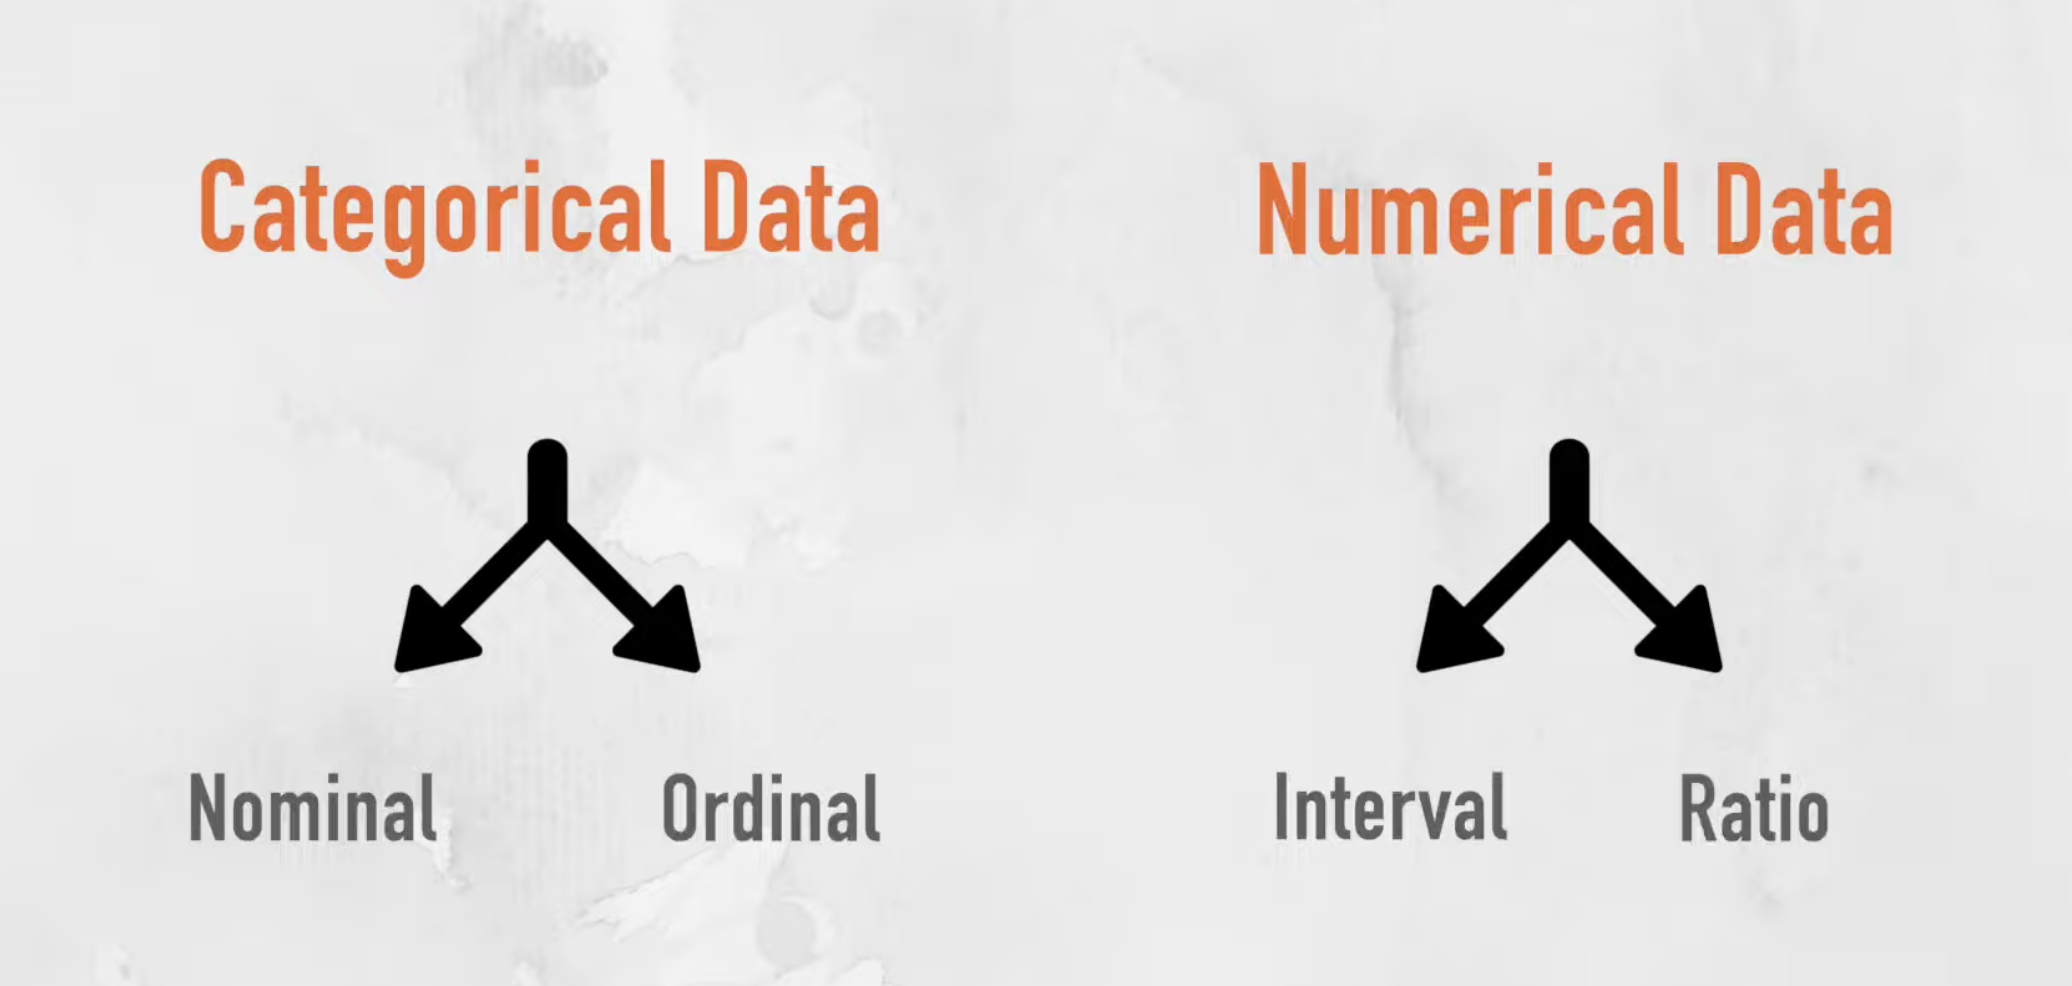

In [6]:
# Dataset Semantic Types (Dictionary - Key: Column Name, Value: Semantic Type)
semantic_types = {
    'student_id':'nominal identifier',
    'study_mode':'nominal categorical',
    'prior_programming_level':'ordinal categorical',
    'weekly_study_hours':'ratio continuous',
    'attendance_percent':'ratio continuous',
    'practice_attempts':'ratio discrete count',
    'lab_temperature_c':'interval continuous',
    'satisfaction':'ordinal categorical',
    'enrolment_date':'temporal',
    'passed':'binary categorical',
    'assessment_score':'ratio continuous bounded outcome'
}

# To convert the dictionary to a DataFrame for display, we can use the following code:
#semantic_types_df = pd.DataFrame(list(semantic_types.items()), columns=['Column Name', 'Semantic Type'])
semantic_types_table = pd.Series(semantic_types, name='semantic_type').to_frame()
semantic_types_table


,semantic_type
student_id,nominal identifier
study_mode,nominal categorical
prior_programming_level,ordinal categorical
weekly_study_hours,ratio continuous
attendance_percent,ratio continuous
practice_attempts,ratio discrete count
lab_temperature_c,interval continuous
satisfaction,ordinal categorical
enrolment_date,temporal
passed,binary categorical


### TASK 4 — Nominal and ordinal variables (15 minutes)
Count study modes; define ordered categories for programming level and satisfaction; sort five rows by level.

In [7]:
study_mode_counts = students['study_mode'].value_counts(dropna=False)
study_mode_counts

study_mode
On-campus    29
Hybrid       18
Online       11
NaN           2
Name: count, dtype: int64

In [8]:
level_order = ['Beginner', 'Intermediate', 'Advanced']
satisfaction_order = ['Very dissatisfied', 'Dissatisfied', 'Neutral', 'Satisfied', 'Very satisfied']

# Convert programming level to an ordered categorical type
students['prior_programming_level'] = pd.Categorical(
    students['prior_programming_level'], 
    categories=level_order, 
    ordered=True
)

students['satisfaction'] = pd.Categorical(
    students['satisfaction'], 
    categories=satisfaction_order, 
    ordered=True
)

students_sorted_by_level = students.sort_values(by='prior_programming_level')
display(students_sorted_by_level[['student_id', 'prior_programming_level']].head(5))

students_sorted_by_satisfaction = students.sort_values(by='satisfaction')
display(students_sorted_by_satisfaction[['student_id', 'satisfaction']].head(5))


,student_id,prior_programming_level
47,CS1048,Beginner
34,CS1035,Beginner
33,CS1034,Beginner
32,CS1033,Beginner
38,CS1039,Beginner


,student_id,satisfaction
56,CS1057,Very dissatisfied
0,CS1001,Dissatisfied
2,CS1003,Dissatisfied
53,CS1054,Dissatisfied
50,CS1051,Dissatisfied


### TASK 5 — Numeric variables (10 minutes)
Summarise numeric columns and explain why 20°C is not twice 10°C.

In [9]:
numerical_columns = ['weekly_study_hours', 
                     'attendance_percent', 
                     'practice_attempts', 
                     'lab_temperature_c', 
                     'assessment_score'
]
# describe() returns summary statistics for numerical columns by default
numerical_summary = students[numerical_columns].describe()
display(numerical_summary)

,weekly_study_hours,attendance_percent,practice_attempts,lab_temperature_c,assessment_score
count,57.000000,60.000000,60.000000,60.000000,60.000000
mean,7.770175,82.593333,3.366667,21.423333,73.566667
std,3.004934,11.775439,2.428410,2.094251,12.539249
min,1.600000,56.200000,0.000000,16.000000,42.000000
25%,5.500000,74.725000,1.000000,20.300000,65.000000
50%,7.500000,81.650000,3.000000,21.500000,75.000000
75%,9.200000,89.700000,6.000000,22.825000,82.000000
max,16.700000,115.000000,7.000000,25.600000,100.000000


### TASK 6 — Missingness and cardinality (10 minutes)
Build a report with missing count, missing percentage and unique count.

## Data-Quality Audit

Data quality is not limited to missing values. A practical audit should look for:

- missing values;
- duplicate records or duplicate identifiers;
- values outside valid ranges;
- inconsistent category labels;
- impossible dates or temporal order;
- unexpected data types;
- extreme values; and
- unusually high or low cardinality.

Cleaning choices should be justified. Imputation is not automatically correct, and deleting every problematic row can introduce bias or remove valuable evidence about the data-collection process.

In [10]:
# Calculate the number of missing values in each column of the students DataFrame
missing_count = students.isna().sum()

# Calculate the percentage of missing values in each column of the students DataFrame
# isna().mean() gives the fraction missing because it calculates the mean of the boolean values (True=1, False=0)
# mult(100) converts the fraction to a percentage, and 
# round(1) rounds to one decimal place
missing_percent = (
    students.isna()
    .mean()
    .mul(100)
    .round(1)
)
# Count distinct (unique) values in each column of the students DataFrame, ignoring null values
unique_counts = students.nunique(dropna=True)

quality_report = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent,
    'unique_count': unique_counts
})
quality_report


,missing_count,missing_percent,unique_count
student_id,0,0.0,59
study_mode,2,3.3,3
prior_programming_level,0,0.0,3
weekly_study_hours,3,5.0,45
attendance_percent,0,0.0,53
practice_attempts,0,0.0,8
lab_temperature_c,0,0.0,40
satisfaction,0,0.0,5
enrolment_date,0,0.0,15
passed,0,0.0,2


### TASK 7 — Invalid values and duplicates (10 minutes)
Find duplicate student IDs and attendance outside 0–100. Explain why they matter.

In [11]:
# duplicated() marks repeated student_id values
# subset='student_id' specifies that we want to check for duplicates based on the 'student_id' column
# keep=False marks all duplicates as True, not just the first or last occurrence
duplicate_mask = students.duplicated(
    subset='student_id',
    keep=False
)

duplicate_ids = (
    students
    .loc[duplicate_mask]
    .sort_values(by='student_id')
)

# Display the duplicate student_id rows
display(duplicate_ids)

valid_attendance_mask = students['attendance_percent'].between(0, 100, inclusive='both')
# The ~ operator negates the boolean mask, so we select rows where attendance_percent is NOT between 0 and 100
# Missing values (NaN) will also be included in the invalid_attendance_rows DataFrame because they do not satisfy the condition
invalid_attendance_rows = students.loc[~valid_attendance_mask]
display(invalid_attendance_rows)

,student_id,study_mode,prior_programming_level,weekly_study_hours,attendance_percent,practice_attempts,lab_temperature_c,satisfaction,enrolment_date,passed,assessment_score
11,CS1012,Hybrid,Beginner,5.2,100.0,3,19.3,Dissatisfied,2026-01-13,False,83.0
12,CS1012,Online,Advanced,6.8,100.0,0,18.6,Satisfied,2026-01-17,True,77.0


,student_id,study_mode,prior_programming_level,weekly_study_hours,attendance_percent,practice_attempts,lab_temperature_c,satisfaction,enrolment_date,passed,assessment_score
33,CS1034,On-campus,Beginner,4.9,115.0,1,17.1,Neutral,2026-01-12,False,49.0


### TASK 8 — Clean a copy (15 minutes)
Fill missing study mode with Unknown; median-impute study hours; replace invalid attendance then median-impute; remove duplicate IDs; verify.

In [12]:
# Work on a copy of the original students DataFrame to avoid modifying it directly
students_clean = students.copy()

students_clean['study_mode'] = (
    students_clean['study_mode']
    .fillna('Unknown')
)

# Calculate the median before filling missing study hours
# The median is less sensitive to extreme values (outliers) than the mean, making it a better choice for imputation in this case

# 3,6,2,100,11,8,6,3,2
# mean (average) = (3 + 6 + 2 + 100 + 11 + 8 + 6 + 3 + 2) / 9 = 139 / 9 ≈ 15.44
# median = 6 (the middle value when the numbers are sorted: 2, 2, 3, 3, 6, 6, 8, 11, 100)

median_study_hours = students_clean['weekly_study_hours'].median()

students_clean['weekly_study_hours'] = (
    students_clean['weekly_study_hours']
    .fillna(median_study_hours)
)

#Handle incorrectly inputted data (example: attendance 115%)
invalid_attendance_mask = ~students_clean['attendance_percent'].between(0, 100, inclusive='both')

# Replacing invalid attendance_percent values with NaN (missing value) to handle them later
students_clean.loc[invalid_attendance_mask, 'attendance_percent'] = np.nan

# Handling missing data (NaN)
median_attendance = students_clean['attendance_percent'].median()

students_clean['attendance_percent'] = (
    students_clean['attendance_percent']
    .fillna(median_attendance)
)

# Remove repeated student identifiers, keeping only the first occurrence
students_clean = students_clean.drop_duplicates(subset='student_id', keep='first')

# Verify how many missing values remain
remaining_missing = students_clean.isna().sum()
display(remaining_missing)


student_id                 0
study_mode                 0
prior_programming_level    0
weekly_study_hours         0
attendance_percent         0
practice_attempts          0
lab_temperature_c          0
satisfaction               0
enrolment_date             0
passed                     0
assessment_score           0
dtype: int64

### TASK 9 — Distribution and balance (15 minutes)
Draw histograms, calculate categorical cardinality, and calculate passed-class proportions. Comment briefly.

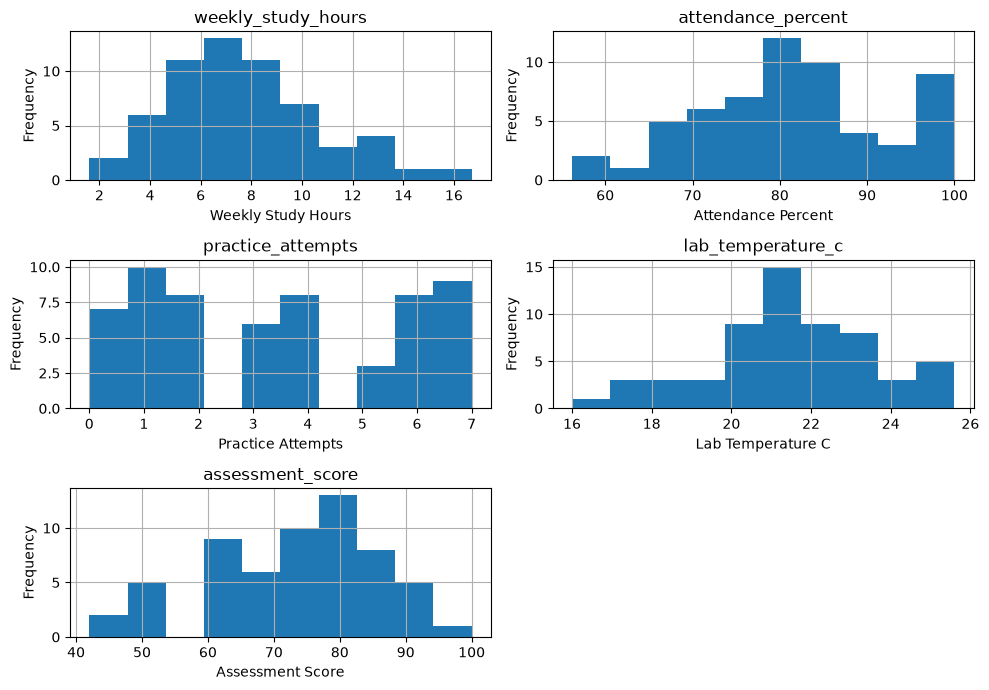

In [13]:
plot_columns = [
    'weekly_study_hours', 
    'attendance_percent', 
    'practice_attempts', 
    'lab_temperature_c', 
    'assessment_score'
]


# hist() creates a histogram for each column in plot_columns
# figsize controls the width and height of the complete figure (in inches)
axes = students_clean[plot_columns].hist(figsize=(10, 7))

# Add readable axis labels to each subplot
for column, ax in zip(plot_columns, axes.flatten()):
    ax.set_xlabel(column.replace('_', ' ').title())
    ax.set_ylabel('Frequency')

# reduces overlap between subplots and ensures that labels and titles are displayed properly
plt.tight_layout() 

plt.show()

In [14]:
categorical_like_columns = students_clean.select_dtypes(
    include=['object', 'category', 'bool'])

categorical_cardinality = categorical_like_columns.nunique(dropna=True)
display(categorical_cardinality)

# value_counts(normalize=true) returns proportions rather than raw counts
class_proportions = (
    students_clean['passed']
    .value_counts(normalize=True)
    .rename('proportion')
)
display(class_proportions)

/var/folders/zk/xqpn6__s2k93g1xrt9347rdh0000gn/T/ipykernel_48909/2716542390.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_like_columns = students_clean.select_dtypes(


student_id                 59
study_mode                  4
prior_programming_level     3
satisfaction                5
passed                      2
dtype: int64

passed
True     0.694915
False    0.305085
Name: proportion, dtype: float64

### TASK 10 — Sensor data (15 minutes)
Inspect the data, group by room, plot CO₂ over time and explain chronological splitting.

In [15]:
display(sensors.head())
sensors.info

,timestamp,room,temperature_c,humidity_percent,co2_ppm,occupied
0,2026-02-02 09:00:00,Lab-A,19.89,57.67,757.0,True
1,2026-02-02 09:15:00,Lab-C,20.41,56.66,715.0,True
2,2026-02-02 09:30:00,Lab-C,19.41,60.61,584.0,True
3,2026-02-02 09:45:00,Lab-A,20.21,56.48,717.0,True
4,2026-02-02 10:00:00,Lab-B,20.83,56.14,557.0,True


<bound method DataFrame.info of              timestamp   room  temperature_c  humidity_percent  co2_ppm  \
0  2026-02-02 09:00:00  Lab-A          19.89             57.67    757.0   
1  2026-02-02 09:15:00  Lab-C          20.41             56.66    715.0   
2  2026-02-02 09:30:00  Lab-C          19.41             60.61    584.0   
3  2026-02-02 09:45:00  Lab-A          20.21             56.48    717.0   
4  2026-02-02 10:00:00  Lab-B          20.83             56.14    557.0   
..                 ...    ...            ...               ...      ...   
91 2026-02-03 07:45:00  Lab-C          16.99             36.85    513.0   
92 2026-02-03 08:00:00  Lab-C          18.60             40.37    681.0   
93 2026-02-03 08:15:00  Lab-B          18.51             38.95    700.0   
94 2026-02-03 08:30:00  Lab-C          18.22             37.44    608.0   
95 2026-02-03 08:45:00  Lab-B          18.13             43.39    792.0   

    occupied  
0       True  
1       True  
2       True  
3      

In [16]:
room_groups = sensors.groupby('room')

room_summary = room_groups.agg(
    readings=('timestamp', 'size'),
    mean_temperature=('temperature_c', 'mean'),
    mean_humidity=('humidity_percent', 'mean'),
    mean_co2=('co2_ppm', 'mean'),
    occupancy=('occupied', 'mean')
)

room_summary = room_summary.round(2)

display(room_summary)

,readings,mean_temperature,mean_humidity,mean_co2,occupancy
room,,,,,
Lab-A,27,20.50,51.06,653.15,0.59
Lab-B,39,19.99,47.15,609.92,0.69
Lab-C,30,19.41,46.08,633.24,0.73


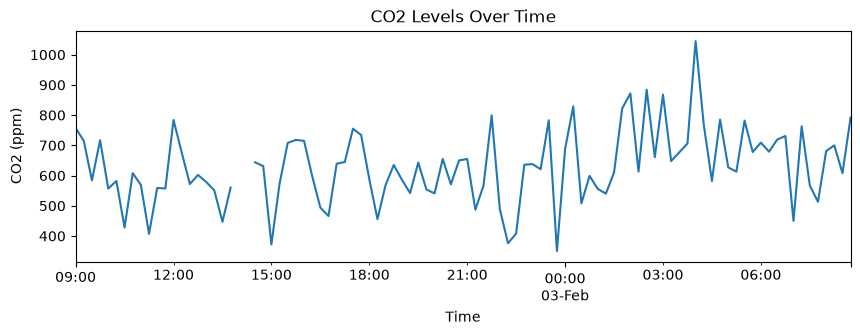

In [17]:
sensors_chronological = sensors.sort_values(by='timestamp')

# Set timestamp as the index so it becomes on the x-axis of the plot (horizontal)
co2_series = (
    sensors_chronological
    .set_index('timestamp')['co2_ppm']
)

co2_series.plot(figsize=(10, 3), title='CO2 Levels Over Time', ylabel='CO2 (ppm)', xlabel='Time')

plt.show()

### TASK 11 — JSON, lists and text (15 minutes)
Add message length and tag count; turn tags into binary columns; identify the unstructured text column.

In [21]:
display(tickets_df.head())

ticket_dtypes = tickets_df.dtypes.astype(str)
display(ticket_dtypes)

,ticket_id,created_at,priority,tags,message,resolved,response_minutes
0,TKT-300,2026-02-03 08:00:00,low,"[login, student, repeat-contact]",Student reports a login problem. The issue aff...,False,54.0
1,TKT-301,2026-02-03 11:00:00,medium,"[database, student]",Student reports a database problem. The issue ...,True,222.0
2,TKT-302,2026-02-03 14:00:00,high,"[network, student]",Student reports a network problem. The issue a...,True,NaN
3,TKT-303,2026-02-03 17:00:00,urgent,"[assessment, student, repeat-contact]",Student reports a assessment problem. The issu...,True,129.0
4,TKT-304,2026-02-03 20:00:00,low,"[software installation, student]",Student reports a software installation proble...,False,107.0


ticket_id               str
created_at              str
priority                str
tags                 object
message                 str
resolved               bool
response_minutes    float64
dtype: str

In [24]:
# Added message_length column to tickets_df to store the length of each message
tickets_df["message_length"] = tickets_df["message"].str.len()

# Added tag count column to tickets_df to store the number of tags associated with each ticket
tickets_df["tag_count"] = tickets_df["tags"].str.len()

ticket_summary_columns = [
    "priority",
    "resolved", 
    "response_minutes", 
    "message_length", 
    "tag_count"
]

ticket_summary = tickets_df[ticket_summary_columns].describe(include='all').round(2)

display(ticket_summary)


,priority,resolved,response_minutes,message_length,tag_count
count,18,18,16.00,18.00,18.00
unique,4,2,NaN,NaN,NaN
top,low,True,NaN,NaN,NaN
freq,5,13,NaN,NaN,NaN
mean,NaN,NaN,117.44,102.33,2.33
std,NaN,NaN,70.03,5.51,0.49
min,NaN,NaN,5.00,96.00,2.00
25%,NaN,NaN,70.75,99.00,2.00
50%,NaN,NaN,109.50,101.00,2.00
75%,NaN,NaN,161.75,103.50,3.00


In [29]:
# explode() turns each list element in the "tags" column into a separate row, effectively flattening the list of tags for each ticket. 
# This allows for easier analysis of individual tags across all tickets.
exploded_tags_df = tickets_df["tags"].explode()

# str.getdummies() creates one idicator (dummy) variable column for each unique tag, with 1 indicating the presence of that tag and 0 indicating its absence.
tag_dummies_long = exploded_tags_df.str.get_dummies()

tag_indicators = tag_dummies_long.groupby(level=0).max()

# Remove the original "tags" and "message"
base_tickets_df = tickets_df.drop(columns=["tags","message"])

# Join the base ticket DataFrame with the tag indicator columns to create a final feature set for analysis or modeling.
ticket_features = pd.concat([base_tickets_df, tag_indicators], axis=1)

display(exploded_tags_df)
display(tag_dummies_long)
display(tag_indicators)
display(ticket_features)

0                     login
0                   student
0            repeat-contact
1                  database
1                   student
2                   network
2                   student
3                assessment
3                   student
3            repeat-contact
4     software installation
4                   student
5                     login
5                   student
6                  database
6                   student
6            repeat-contact
7                   network
7                   student
8                assessment
8                   student
9     software installation
9                   student
9            repeat-contact
10                    login
10                  student
11                 database
11                  student
12                  network
12                  student
12           repeat-contact
13               assessment
13                  student
14    software installation
14                  student
15                  

,assessment,database,login,network,repeat-contact,software installation,student
0,0,0,1,0,0,0,0
0,0,0,0,0,0,0,1
0,0,0,0,0,1,0,0
1,0,1,0,0,0,0,0
1,0,0,0,0,0,0,1
2,0,0,0,1,0,0,0
2,0,0,0,0,0,0,1
3,1,0,0,0,0,0,0
3,0,0,0,0,0,0,1
3,0,0,0,0,1,0,0


,assessment,database,login,network,repeat-contact,software installation,student
0,0,0,1,0,1,0,1
1,0,1,0,0,0,0,1
2,0,0,0,1,0,0,1
3,1,0,0,0,1,0,1
4,0,0,0,0,0,1,1
5,0,0,1,0,0,0,1
6,0,1,0,0,1,0,1
7,0,0,0,1,0,0,1
8,1,0,0,0,0,0,1
9,0,0,0,0,1,1,1


,ticket_id,created_at,priority,resolved,response_minutes,message_length,tag_count,assessment,database,login,network,repeat-contact,software installation,student
0,TKT-300,2026-02-03 08:00:00,low,False,54.0,96,3,0,0,1,0,1,0,1
1,TKT-301,2026-02-03 11:00:00,medium,True,222.0,102,2,0,1,0,0,0,0,1
2,TKT-302,2026-02-03 14:00:00,high,True,NaN,99,2,0,0,0,1,0,0,1
3,TKT-303,2026-02-03 17:00:00,urgent,True,129.0,104,3,1,0,0,0,1,0,1
4,TKT-304,2026-02-03 20:00:00,low,False,107.0,112,2,0,0,0,0,0,1,1
5,TKT-305,2026-02-03 23:00:00,medium,True,72.0,99,2,0,0,1,0,0,0,1
6,TKT-306,2026-02-04 02:00:00,high,True,155.0,100,3,0,1,0,0,1,0,1
7,TKT-307,2026-02-04 05:00:00,urgent,True,182.0,101,2,0,0,0,1,0,0,1
8,TKT-308,2026-02-04 08:00:00,low,False,5.0,101,2,1,0,0,0,0,0,1
9,TKT-309,2026-02-04 11:00:00,medium,True,134.0,115,3,0,0,0,0,1,1,1


### TASK 12 — Prepare features (15 minutes)
Remove identifier, target, score and date; identify numeric/categorical columns; one-hot encode; compare shapes; discuss ordinal encoding.

## Machine-learning implications

Before modelling, columns are usually divided into:

- **features**: inputs available to the model;
- **target**: the value to predict;
- **identifiers**: useful for joining or tracing records, but generally not predictive features;
- **potential leakage variables**: values that reveal the target or occur after the prediction time.

Categorical variables often require encoding. One-hot encoding creates a binary indicator for each category. Ordinal variables may alternatively use an order-preserving encoding, but only when that order is genuinely meaningful.

> **Important:** Data cleaning, imputation, scaling, and encoding should normally be fitted on training data only, then applied unchanged to validation and test data.

In [34]:
features = students_clean.drop(
    columns=['student_id','passed','assessment_score', 'enrolment_date']
)
display(features)

target = students_clean['passed']

numerical_cols = (
    features.select_dtypes(include=['number']).columns.tolist()
)
categorical_cols = (
    features.select_dtypes(include=['object', 'category','bool']).columns.tolist()
)

# encoding is the process of converting categorical variables into a numerical format that can be used by machine learning algorithms. 
# One common method is one-hot encoding, which creates binary columns for each category in a categorical variable.
encoded = pd.get_dummies(features, columns=categorical_cols, drop_first=False, dtype=int)

# display(numerical_cols)
display(categorical_cols)
display(encoded.head())


,study_mode,prior_programming_level,weekly_study_hours,attendance_percent,practice_attempts,lab_temperature_c,satisfaction
0,Hybrid,Intermediate,12.8,80.6,6,23.2,Dissatisfied
1,On-campus,Intermediate,7.3,85.4,4,21.3,Very satisfied
2,Hybrid,Intermediate,4.9,97.7,7,21.8,Dissatisfied
3,Online,Intermediate,8.5,84.6,6,21.1,Very satisfied
4,On-campus,Intermediate,8.7,77.1,6,21.0,Very satisfied
5,Hybrid,Intermediate,7.5,95.3,4,19.4,Satisfied
6,Hybrid,Intermediate,10.5,87.1,2,21.7,Satisfied
7,Hybrid,Beginner,9.1,100.0,3,20.8,Satisfied
8,Unknown,Beginner,12.4,84.2,0,25.6,Very satisfied
9,On-campus,Beginner,4.4,67.3,2,24.5,Neutral


/var/folders/zk/xqpn6__s2k93g1xrt9347rdh0000gn/T/ipykernel_48909/1631636505.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  features.select_dtypes(include=['object', 'category','bool']).columns.tolist()


['study_mode', 'prior_programming_level', 'satisfaction']

,weekly_study_hours,attendance_percent,practice_attempts,lab_temperature_c,study_mode_Hybrid,study_mode_On-campus,study_mode_Online,study_mode_Unknown,prior_programming_level_Beginner,prior_programming_level_Intermediate,prior_programming_level_Advanced,satisfaction_Very dissatisfied,satisfaction_Dissatisfied,satisfaction_Neutral,satisfaction_Satisfied,satisfaction_Very satisfied
0,12.8,80.6,6,23.2,1,0,0,0,0,1,0,0,1,0,0,0
1,7.3,85.4,4,21.3,0,1,0,0,0,1,0,0,0,0,0,1
2,4.9,97.7,7,21.8,1,0,0,0,0,1,0,0,1,0,0,0
3,8.5,84.6,6,21.1,0,0,1,0,0,1,0,0,0,0,0,1
4,8.7,77.1,6,21.0,0,1,0,0,0,1,0,0,0,0,0,1


### TASK 13 — Reusable property report (15 minutes)
Write `property_report(df)` with column, dtype, missing, unique and example. Run it on all datasets.

In [20]:
def property_report(df):
    # TODO
    pass

## Exit check (5 minutes)
Answer the five questions from the lecturer notebook in Markdown.